# Dilated CNN for IMDb Sentiment Classification

A GitHub-ready deep-learning project using the IMDb dataset from Hugging Face.

## What is Dilated CNN?

A dilated convolution inserts gaps between kernel elements. With dilation rates such as
`1, 2, 4, 8`, the model can capture wider contextual patterns without using a very large kernel.

## Pipeline

`Raw text → TextVectorization → Embedding → Dilated Conv1D blocks → GlobalMaxPooling → Dense → Sigmoid`

## Evaluation

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix
- Heatmap
- ROC curve
- AUC
- Training/validation curves
- Model comparison-ready prediction function

## Major fixes in this version

The original notebook produced ~0.50 accuracy and almost all positive reviews were classified as negative. The revised notebook addresses this by fixing token fragmentation, increasing sequence/context coverage, using residual dilated blocks, reducing excessive dropout, lowering the learning rate, monitoring validation AUC, tuning the decision threshold on validation data, and adding explicit false-positive/false-negative analysis.


In [1]:
# Install once in Colab/Kaggle if needed
# !pip install -q datasets tensorflow scikit-learn pandas numpy matplotlib seaborn

## 1. Imports and configuration

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Improved configuration
VOCAB_SIZE = 30000
MAX_LEN = 400
EMBED_DIM = 128
FILTERS = 128
KERNEL_SIZE = 5
DILATION_RATES = [1, 2, 4, 8, 16]
DROPOUT = 0.10
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 3e-4

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Improved Dilated CNN configuration loaded.")


TensorFlow version: 2.20.0
Improved Dilated CNN configuration loaded.


## 2. Load IMDb dataset from Hugging Face

In [3]:
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print(dataset["train"][0])
print(dataset["test"][0])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

## 3. Convert to DataFrames

In [4]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())

print("\nLabel distribution:")
print(train_df["label"].value_counts().sort_index())

Train shape: (25000, 2)
Test shape : (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0



Label distribution:
label
0    12500
1    12500
Name: count, dtype: int64


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Keep apostrophes so negations such as don't / wasn't are not destroyed.
    text = re.sub(r"[^a-z0-9!?.,'\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

display(train_df[["clean_text", "label"]].head())


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9!?.,'\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

display(train_df[["clean_text", "label"]].head())

,clean_text,label
0,i rented i am curious yellow from my video sto...,0
1,i am curious yellow is a risible and pretentio...,0
2,if only to avoid making this type of film in t...,0
3,this film was probably inspired by godard's ma...,0
4,"oh, brother...after hearing about this ridicul...",0


## 5. Train/validation/test split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean_text"].values,
    train_df["label"].values,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"].values
)

X_test = test_df["clean_text"].values
y_test = test_df["label"].values

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 20000
Validation: 5000
Test: 25000


## 6. TextVectorization

In [7]:
# Important fix: normalize case/punctuation inside the vectorizer and add bigrams.
# This prevents the vocabulary from fragmenting words such as "good" and "good!".
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    ngrams=2
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(X_train).batch(256)
)

vocab = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("Sample vocabulary:", vocab[:30])


Vocabulary size: 30000
Sample vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('movie'), np.str_('but'), np.str_('of the'), np.str_('film'), np.str_('on'), np.str_('not'), np.str_('you'), np.str_('are'), np.str_('his'), np.str_('have'), np.str_('be'), np.str_('he'), np.str_('one')]


## 7. Build TensorFlow datasets

In [8]:
def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

print("Datasets ready.")

Datasets ready.


## 8. Dilated CNN block

For a 1D convolution, the receptive field increases with dilation.

For kernel size `k` and dilation `d`, the effective kernel width is:

`effective_width = k + (k - 1) × (d - 1)`

With `kernel_size=3`:
- dilation 1 → effective width 3
- dilation 2 → effective width 5
- dilation 4 → effective width 9
- dilation 8 → effective width 17

The model stacks several dilated Conv1D layers to capture local and wider text patterns.

In [9]:
def residual_dilated_block(x, filters, kernel_size, dilation_rate, dropout):
    shortcut = x

    x = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.SpatialDropout1D(dropout)(x)

    x = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Projection makes the residual path compatible when channel count changes.
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters, 1, padding="same", use_bias=False
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation("relu")(x)
    return x


def build_dilated_cnn():
    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")

    x = vectorizer(inputs)
    x = tf.keras.layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBED_DIM,
        embeddings_initializer="uniform",
        name="embedding"
    )(x)
    x = tf.keras.layers.SpatialDropout1D(0.05)(x)

    for rate in DILATION_RATES:
        x = residual_dilated_block(
            x,
            filters=FILTERS,
            kernel_size=KERNEL_SIZE,
            dilation_rate=rate,
            dropout=DROPOUT
        )

    # Three complementary summaries reduce dependence on one pooling operation.
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(x)
    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(x)

    attention_scores = tf.keras.layers.Dense(1)(x)
    attention_scores = tf.keras.layers.Softmax(axis=1)(attention_scores)
    attention_pool = tf.keras.layers.Lambda(
        lambda z: tf.reduce_sum(z[0] * z[1], axis=1)
    )([x, attention_scores])

    x = tf.keras.layers.Concatenate()([
        max_pool, avg_pool, attention_pool
    ])
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    outputs = tf.keras.layers.Dense(
        1, activation="sigmoid", name="sentiment"
    )(x)

    model = tf.keras.Model(
        inputs, outputs, name="Improved_DilatedCNN_IMDb"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipnorm=1.0
        ),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

model = build_dilated_cnn()
model.summary()


Model: "Improved_DilatedCNN_IMDb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 400)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 400, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 400, 128)  │     81,920 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 400, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 400, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 400, 128)  │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 400, 128)  │     81,920 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 400, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 400, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 400, 128)  │     81,920 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 400, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 400, 128)  │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 400, 128)  │     81,920 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,722,562 (18.02 MB)

 Trainable params: 4,719,746 (18.00 MB)

 Non-trainable params: 2,816 (11.00 KB)

## 9. Train the Dilated CNN

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_dilated_cnn_improved.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5072 - auc: 0.5102 - loss: 0.8266 - precision: 0.5067 - recall: 0.7463
Epoch 1: val_auc improved from None to 0.49334, saving model to ../models/best_dilated_cnn_improved.keras

Epoch 1: finished saving model to ../models/best_dilated_cnn_improved.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 116ms/step - accuracy: 0.5101 - auc: 0.5135 - loss: 0.7632 - precision: 0.5083 - recall: 0.6199 - val_accuracy: 0.5000 - val_auc: 0.4933 - val_loss: 1.1375 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6250 - auc: 0.6787 - loss: 0.6344 - precision: 0.6219 - recall: 0.6030
Epoch 2: val_auc improved from 0.49334 to 0.94153, saving model to ../models/best_dilated_cnn_improved.keras

Epoch 2: finished saving model to ../models/best_dilated_cnn_improved.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.7096 - auc: 0.7958 - loss: 0.5416 

## 10. Training and validation visualization

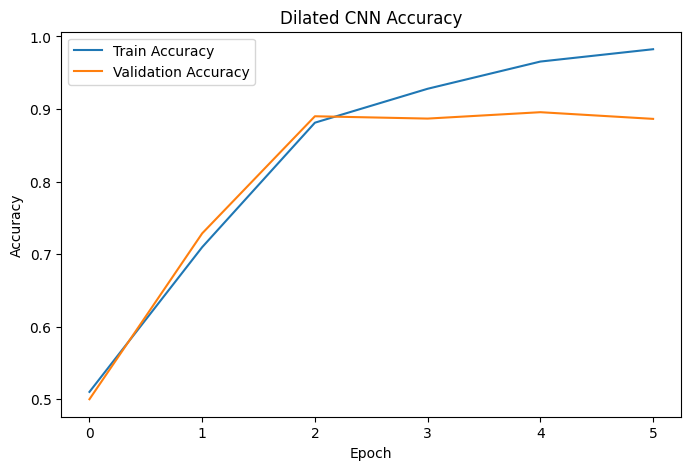

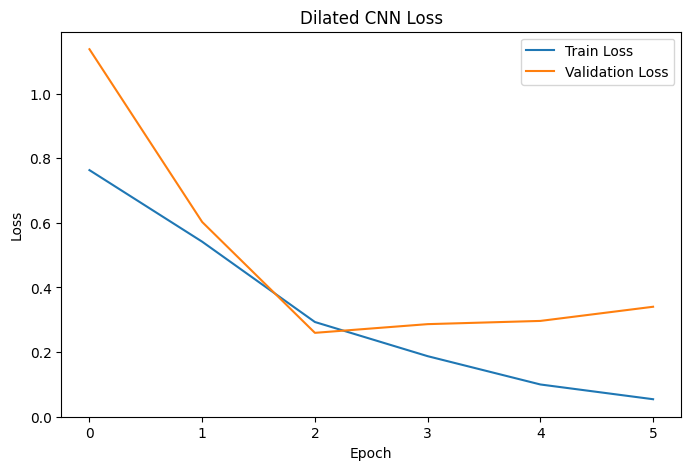

In [11]:
def plot_history(history):
    h = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Validation Accuracy")
    plt.title("Dilated CNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.title("Dilated CNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history)

## 11. Evaluate the model

In [12]:
# Select the decision threshold using VALIDATION data only.
# The test set is kept untouched until the final evaluation.
val_probabilities = model.predict(val_ds, verbose=0).ravel()
thresholds = np.arange(0.30, 0.71, 0.01)
val_f1 = np.array([
    f1_score(y_val, (val_probabilities >= t).astype(int), zero_division=0)
    for t in thresholds
])
best_threshold = float(thresholds[np.argmax(val_f1)])

print("Best validation threshold:", round(best_threshold, 2))
print("Validation F1 at threshold:", round(float(val_f1.max()), 4))

probabilities = model.predict(test_ds, verbose=1).ravel()
predictions = (probabilities >= best_threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions, zero_division=0),
    "Recall": recall_score(y_test, predictions, zero_division=0),
    "F1-score": f1_score(y_test, predictions, zero_division=0),
    "AUC": roc_auc_score(y_test, probabilities)
}

metrics_df = pd.DataFrame([metrics], index=["Improved Dilated CNN"])
display(metrics_df.round(4))


Best validation threshold: 0.63
Validation F1 at threshold: 0.8954
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step


,Accuracy,Precision,Recall,F1-score,AUC
Improved Dilated CNN,0.881,0.8942,0.8643,0.879,0.9533


## 12. Classification report

In [13]:
print(classification_report(
    y_test,
    predictions,
    target_names=["Negative", "Positive"],
    digits=4
))


              precision    recall  f1-score   support

    Negative     0.8687    0.8978    0.8830     12500
    Positive     0.8942    0.8643    0.8790     12500

    accuracy                         0.8810     25000
   macro avg     0.8815    0.8810    0.8810     25000
weighted avg     0.8815    0.8810    0.8810     25000



## 13. Confusion matrix and heatmap

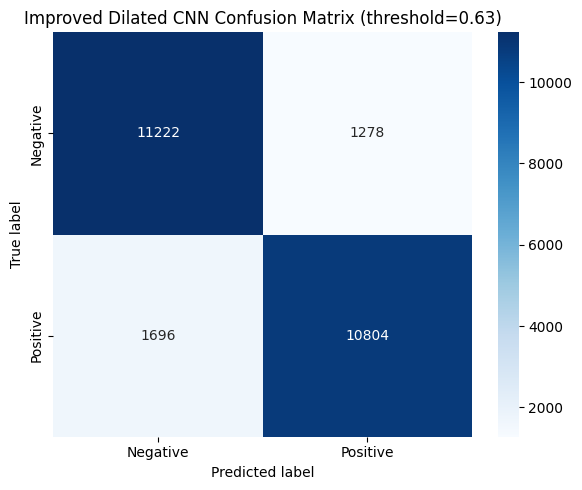

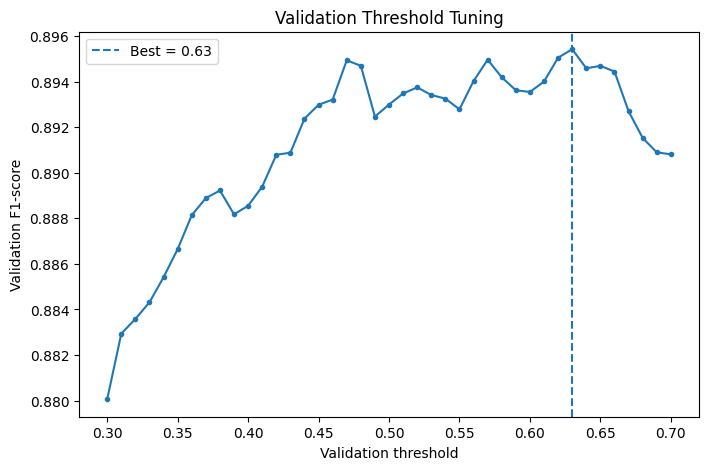

In [14]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title(f"Improved Dilated CNN Confusion Matrix (threshold={best_threshold:.2f})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(thresholds, val_f1, marker="o", markersize=3)
plt.axvline(best_threshold, linestyle="--", label=f"Best = {best_threshold:.2f}")
plt.xlabel("Validation threshold")
plt.ylabel("Validation F1-score")
plt.title("Validation Threshold Tuning")
plt.legend()
plt.show()


## 14. ROC curve and AUC

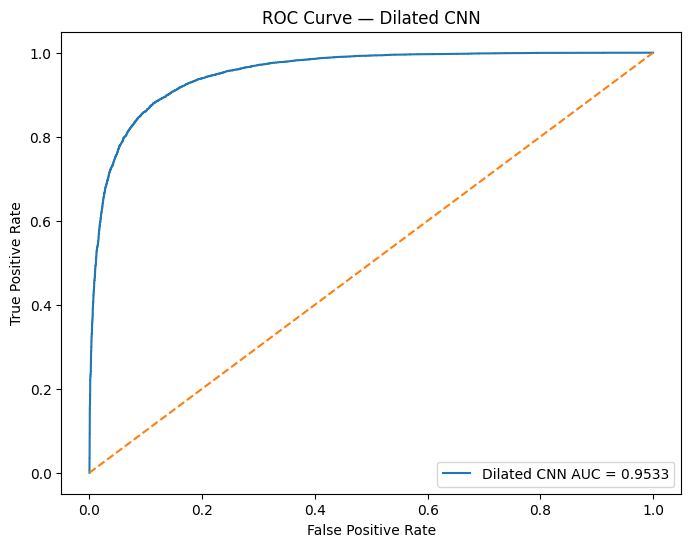

AUC: 0.9533


In [15]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
auc_value = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Dilated CNN AUC = {auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Dilated CNN")
plt.legend()
plt.show()

print("AUC:", round(auc_value, 4))

## 15. Prediction function

In [16]:
def predict_sentiment(text, model=model, threshold=best_threshold):
    text_input = tf.constant([text], dtype=tf.string)
    probability = float(model.predict(text_input, verbose=0)[0][0])

    label = "Positive" if probability >= threshold else "Negative"
    confidence = probability if label == "Positive" else 1 - probability

    return {
        "sentiment": label,
        "probability_positive": probability,
        "confidence": confidence,
        "threshold": threshold
    }

examples = [
    "This movie was fantastic, emotional, and beautifully acted.",
    "The plot was boring and the acting was terrible."
]

for example in examples:
    result = predict_sentiment(example)
    print("Text:", example)
    print("Sentiment:", result["sentiment"])
    print("Positive Probability:", round(result["probability_positive"], 4))
    print("Confidence:", round(result["confidence"], 4))
    print("-" * 80)


Text: This movie was fantastic, emotional, and beautifully acted.
Sentiment: Positive
Positive Probability: 0.963
Confidence: 0.963
--------------------------------------------------------------------------------
Text: The plot was boring and the acting was terrible.
Sentiment: Negative
Positive Probability: 0.1202
Confidence: 0.8798
--------------------------------------------------------------------------------


## Misclassification analysis

This section lists false positives and false negatives so the difficult reviews can be inspected rather than hiding the errors.

In [17]:
results_df = pd.DataFrame({
    "text": test_df["clean_text"].values,
    "true_label": y_test,
    "probability_positive": probabilities,
    "predicted_label": predictions
})

results_df["error_type"] = "Correct"
results_df.loc[(results_df.true_label == 0) & (results_df.predicted_label == 1), "error_type"] = "False Positive"
results_df.loc[(results_df.true_label == 1) & (results_df.predicted_label == 0), "error_type"] = "False Negative"

errors_df = results_df[results_df["error_type"] != "Correct"].copy()
errors_df["confidence"] = np.where(
    errors_df["predicted_label"] == 1,
    errors_df["probability_positive"],
    1 - errors_df["probability_positive"]
)

print("Total misclassified:", len(errors_df))
print("False positives:", int((errors_df.error_type == "False Positive").sum()))
print("False negatives:", int((errors_df.error_type == "False Negative").sum()))

display(
    errors_df.sort_values("confidence", ascending=False)
    [["error_type", "true_label", "predicted_label", "probability_positive", "confidence", "text"]]
    .head(30)
)


Total misclassified: 2974
False positives: 1278
False negatives: 1696


,error_type,true_label,predicted_label,probability_positive,confidence,text
3757,False Positive,0,1,0.999547,0.999547,"i went to see this 3 nights ago here in cork, ..."
5331,False Positive,0,1,0.999303,0.999303,i enjoyed the beautiful scenery in this movie ...
12061,False Positive,0,1,0.999191,0.999191,this movie was pure genius. john waters is bri...
3553,False Positive,0,1,0.998645,0.998645,"this film has the language, the style and the ..."
6844,False Positive,0,1,0.998525,0.998525,"voor een verloren soldaat , for a lost soldier..."
3692,False Positive,0,1,0.998072,0.998072,"another direct to video movie from disney, tha..."
9461,False Positive,0,1,0.997774,0.997774,'helen of troy' follows the story of helen and...
12969,False Negative,1,0,0.003068,0.996932,david morse and andre braugher are very talent...
6268,False Positive,0,1,0.996679,0.996679,scarier than any horror movie ever made becaus...
9209,False Positive,0,1,0.996615,0.996615,a chilling and gory tale of a couple inheritin...


## 16. project structure

```text
dilated-cnn-imdb/
├── notebook/
│   └── Dilated_CNN_IMDb_HuggingFace.ipynb
├── models/
│   ├── best_dilated_cnn.keras
│   └── dilated_cnn_imdb.keras
├── src/
│   └── predict.py
├── README.md
├── requirements.txt
├── .gitignore
└── LICENSE
```

## 17. Limitations and future improvements

- Dilated CNN captures wider context, but it does not model language semantics like a Transformer.
- The dilation rates and kernel size can be tuned.
- Residual connections can make deeper dilated CNNs easier to train.
- Weight decay, pretrained embeddings, and class-weight experiments can be added.
- Compare this model with ordinary CNN, BiLSTM, BiGRU, TCN, and Transformer models.

## 18. Dataset citation

Dataset: `stanfordnlp/imdb` on Hugging Face.

The dataset contains 25,000 labeled training reviews and 25,000 labeled test reviews, with additional unlabeled examples. Labels are

  `0 = negative` and `1 = positive`.

Check the Hugging Face dataset card for current licensing and usage terms before redistributing data.